# Ensemble: weighted blend of NN and LGBM

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import sys
sys.path.append('..')

import mlflow
import numpy as np
import pandas as pd

from src import tracking
from src.data import load_data
from src.metrics import evaluate
from src.postprocess import snap
from src.split import rc_strata, split_breaths

## Data

The same validation breaths as in `lgbm.ipynb` and `nn.ipynb`

In [6]:
train_raw = load_data('../data/train.csv')
_, val_part = split_breaths(train_raw, rc_strata(train_raw))
val_part['nn'] = np.load('../submissions/nn_val_pred.npy')
val_part['lgbm'] = np.load('../submissions/lgbm_val_pred.npy')

insp = val_part[val_part['u_out'] == 0]
p, nn, gb = insp['pressure'].to_numpy(), insp['nn'].to_numpy(), insp['lgbm'].to_numpy()
len(val_part), len(insp)

(1207200, 458014)

## Blend weight

`pred = w·nn + (1 − w)·lgbm`. `w` 

(np.float64(0.91), np.float64(0.36107342283903876))

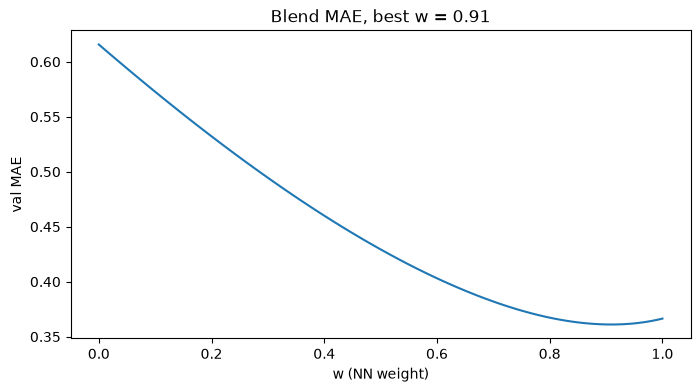

In [7]:
weights = np.linspace(0, 1, 101)
mae = pd.Series([np.abs(w * nn + (1 - w) * gb - p).mean() for w in weights], index=weights)
w_best = round(mae.idxmin(), 2)

mae.plot(figsize=(8, 4), xlabel='w (NN weight)', ylabel='val MAE', title=f'Blend MAE, best w = {w_best}');
w_best, mae.min()

## Comparison

In [8]:
preds = {
    'lgbm': gb,
    'nn': nn,
    'mean': (nn + gb) / 2,
    'blend': w_best * nn + (1 - w_best) * gb,
}
rows = {}
for name, pred in preds.items():
    rows[name] = evaluate(p, pred, insp['u_out'])
    rows[f'{name}_snapped'] = evaluate(p, snap(pred), insp['u_out'])
pd.DataFrame(rows).T

,ME,MAE,RMSE,R2
lgbm,0.012344,0.615717,0.983579,0.988558
lgbm_snapped,0.012307,0.615277,0.983783,0.988553
nn,0.001666,0.366428,0.589902,0.995884
nn_snapped,0.001652,0.365776,0.590216,0.995880
mean,0.007005,0.429380,0.674699,0.994616
mean_snapped,0.006956,0.428809,0.674998,0.994611
blend,0.002627,0.361073,0.580861,0.996009
blend_snapped,0.002609,0.360472,0.581234,0.996004


Error correlation

In [9]:
np.corrcoef(nn - p, gb - p)[0, 1]

np.float64(0.43558267456764704)

## MLflow

In [10]:
tracking.setup()
with mlflow.start_run(run_name='ensemble-v1'):
    mlflow.log_param('w', w_best)
    mlflow.log_metrics(rows['blend'])

runs = mlflow.search_runs(experiment_names=[tracking.EXPERIMENT_NAME])
runs[['tags.mlflow.runName', 'metrics.MAE', 'metrics.RMSE', 'metrics.ME', 'metrics.R2']].dropna(
    subset=['metrics.MAE']
).sort_values('metrics.MAE')

,tags.mlflow.runName,metrics.MAE,metrics.RMSE,metrics.ME,metrics.R2
0,ensemble-v1,0.361073,0.580861,0.002627,0.996009
1,nn_time-v1,0.366428,0.589902,0.001666,0.995884
3,lgbm_inspiration-v1,0.615717,0.983579,0.012344,0.988558
4,lgbm_all_rows-v3,0.619880,0.990268,0.014718,0.988402


## Kaggle submission

In [11]:
test = pd.read_csv('../submissions/nn_raw.csv').merge(
    pd.read_csv('../submissions/lgbm_raw.csv'), on='id', suffixes=('_nn', '_lgbm')
)
blend = w_best * test['pressure_nn'] + (1 - w_best) * test['pressure_lgbm']

for name, pred in {'ens_raw': blend, 'ens_snap': snap(blend)}.items():
    pd.DataFrame({'id': test['id'], 'pressure': pred}).to_csv(f'../submissions/{name}.csv', index=False)
len(test)

4024000

In [12]:
!kaggle competitions submit -c ventilator-pressure-prediction -f ../submissions/ens_raw.csv -m "blend nn+lgbm w={w_best} raw"
!kaggle competitions submit -c ventilator-pressure-prediction -f ../submissions/ens_snap.csv -m "blend nn+lgbm w={w_best} + ADC snap"
!kaggle competitions submissions -c ventilator-pressure-prediction | head -5

100%|████████████████████████████████████████| 101M/101M [00:06<00:00, 16.4MB/s]
Successfully submitted to Google Brain - Ventilator Pressure PredictionWarning: Looks like you're using an outdated `kaggle` version (installed: 2.0.0), please consider upgrading to the latest version (2.2.2)
100%|████████████████████████████████████████| 101M/101M [00:05<00:00, 19.8MB/s]
Successfully submitted to Google Brain - Ventilator Pressure PredictionWarning: Looks like you're using an outdated `kaggle` version (installed: 2.0.0), please consider upgrading to the latest version (2.2.2)
fileName               date                        description                                   status                     publicScore  privateScore  
---------------------  --------------------------  --------------------------------------------  -------------------------  -----------  ------------  
ens_snap.csv           2026-10-01 21:25:06.260000  blend nn+lgbm w=0.91 + ADC snap               SubmissionStatus.PE

In [ ]:
!kaggle competitions submissions -c ventilator-pressure-prediction | head -7

fileName               date                        description                                   status                     publicScore  privateScore  
---------------------  --------------------------  --------------------------------------------  -------------------------  -----------  ------------  
ens_snap.csv           2026-10-01 21:25:06.260000  blend nn+lgbm w=0.91 + ADC snap               SubmissionStatus.COMPLETE  0.3638       0.3659        
ens_raw.csv            2026-10-01 21:24:58.600000  blend nn+lgbm w=0.91 raw                      SubmissionStatus.COMPLETE  0.3644       0.3665        
nn_snap.csv            2026-10-01 19:49:25.540000  nn TimeLinear + ADC snap                      SubmissionStatus.COMPLETE  0.3698       0.3718        
nn_raw.csv             2026-10-01 19:49:20.077000  nn TimeLinear raw                             SubmissionStatus.COMPLETE  0.3704       0.3724        


## Results

Two-stage pipeline: stage 1 = saved predictions of LGBM and NN, stage 2 = weighted blend `0.91·nn + 0.09·lgbm`, with `w` picked on validation (`u_out == 0`).

| Model | Val MAE | Kaggle public | Kaggle private |
|---|---|---|---|
| lgbm_snap | 0.6153 | 0.6138 | 0.6160 |
| nn_snap | 0.3658 | 0.3698 | 0.3718 |
| ens_raw | 0.3611 | 0.3644 | 0.3665 |
| ens_snap | **0.3605** | **0.3638** | **0.3659** |


The error correlation is only 0.44, so the models make partly different mistakes, and a small weight on LGBM cancels some of the NN errors.